In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import joblib

In [2]:
import sys
sys.path.append('../data_preprocessing')

In [3]:
import feature_engineering_scaling as fes 

2025-03-20 18:05:53.869559: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-03-20 18:05:54.795527: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-03-20 18:05:59.071149: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


DECISION TREE MODEL

In [4]:
# Define a function to train and evaluate a decision tree
def train_and_evaluate_decision_tree(X_train, y_train, X_val, y_val, X_test, y_test):
    # Initialize the Decision Tree Classifier
    model = DecisionTreeClassifier(random_state=0)
    
    # Train the model on the training data
    model.fit(X_train, y_train)
    
    # Evaluate on validation set
    y_val_pred = model.predict(X_val)
    val_accuracy = accuracy_score(y_val, y_val_pred)
    print("Validation Accuracy:", val_accuracy)
    print("Validation Classification Report:")
    print(classification_report(y_val, y_val_pred))
    
    # Evaluate on test set
    y_test_pred = model.predict(X_test)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    print("Test Accuracy:", test_accuracy)
    print("Test Classification Report:")
    print(classification_report(y_test, y_test_pred))
    
    return model


In [5]:
X1 = fes.X1
y1 = fes.y1
X2 = fes.X2
y2 = fes.y2

In [6]:
scaler = MinMaxScaler()
X1.loc[:, 'time'] = scaler.fit_transform(X1[['time']])

In [7]:
scaler = MinMaxScaler()
X2.loc[:, 'time'] = scaler.fit_transform(X2[['time']])

In [8]:
#Since the truth need not be one hot encoded for decision tree, spliting of the dataset is done here
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=0)
X1_train, X1_val, y1_train, y1_val = train_test_split(X1_train, y1_train, test_size=0.2, random_state=0)
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=0)
X2_train, X2_val, y2_train, y2_val = train_test_split(X2_train, y2_train, test_size=0.2, random_state=0)

In [9]:
# Model for the First Chain (BiPo214)
print("Training and evaluating Decision Tree on First Chain")
model_dt_1 = train_and_evaluate_decision_tree(X1_train, y1_train, X1_val, y1_val, X1_test, y1_test)

Training and evaluating Decision Tree on First Chain
Validation Accuracy: 0.7380790555216525
Validation Classification Report:
              precision    recall  f1-score   support

         0.0       0.74      0.76      0.75    172592
         1.0       0.62      0.62      0.62    173056
         2.0       0.92      0.91      0.92    173445
         3.0       0.67      0.66      0.67    172421

    accuracy                           0.74    691514
   macro avg       0.74      0.74      0.74    691514
weighted avg       0.74      0.74      0.74    691514

Test Accuracy: 0.7380262658608594
Test Classification Report:
              precision    recall  f1-score   support

         0.0       0.74      0.75      0.75    215636
         1.0       0.63      0.62      0.62    217177
         2.0       0.92      0.91      0.92    216607
         3.0       0.67      0.67      0.67    214972

    accuracy                           0.74    864392
   macro avg       0.74      0.74      0.74    864

In [10]:
# Model for the Second Chain (BiPo212)
print("Training and evaluating Decision Tree on 2nd Dataset")
model_dt_2 = train_and_evaluate_decision_tree(X2_train, y2_train, X2_val, y2_val, X2_test, y2_test)


Training and evaluating Decision Tree on 2nd Dataset
Validation Accuracy: 0.7365153171267748
Validation Classification Report:
              precision    recall  f1-score   support

         0.0       0.78      0.80      0.79    172400
         3.0       0.68      0.67      0.68    173161
         4.0       0.62      0.62      0.62    169474
         5.0       0.87      0.86      0.86    169297

    accuracy                           0.74    684332
   macro avg       0.74      0.74      0.74    684332
weighted avg       0.74      0.74      0.74    684332

Test Accuracy: 0.7356557928023241
Test Classification Report:
              precision    recall  f1-score   support

         0.0       0.78      0.79      0.78    215594
         3.0       0.68      0.67      0.67    215577
         4.0       0.62      0.62      0.62    212143
         5.0       0.87      0.86      0.86    212101

    accuracy                           0.74    855415
   macro avg       0.74      0.74      0.74    855

GRID SEARCH

In [11]:
# Now to fnd the best hyperparameters for the best model, define the GridSearch function
def perform_grid_search(X_train, y_train, param_grid):
    # Initialize the Decision Tree model
    dt = DecisionTreeClassifier(random_state=0)
    
    # Set up GridSearchCV with cross-validation
    grid_search = GridSearchCV(estimator=dt, param_grid=param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=2)
    
    # Perform the grid search on the training data
    grid_search.fit(X_train, y_train)
    
    # Output the best parameters and best score
    print("Best Parameters:", grid_search.best_params_)
    print("Best Cross-Validation Accuracy:", grid_search.best_score_)
    
    return grid_search.best_estimator_

In [12]:
# Define the hyperparameter grid for Grid Search
param_grid = {
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
}

# Grid Search For BiPo214

In [13]:
# Perform Grid Search for BiPo 214
print("Performing Grid Search for BiPo 214")
best_dt_model_1 = perform_grid_search(X1_train, y1_train, param_grid)

Performing Grid Search for BiPo 214
Fitting 3 folds for each of 36 candidates, totalling 108 fits
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2; total time= 1.8min
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2; total time= 2.0min
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2; total time= 2.0min
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=5; total time= 2.0min
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=5; total time= 1.9min
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=5; total time= 1.9min
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=10; total time= 1.9min
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=10; total time= 2.0min
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=10; total time= 1.9min
[CV] END max_depth=None, min_samples_leaf=2, min_samples_split=2; total time= 1.8min
[CV] END max_depth=None, min_samples_leaf=2, min_

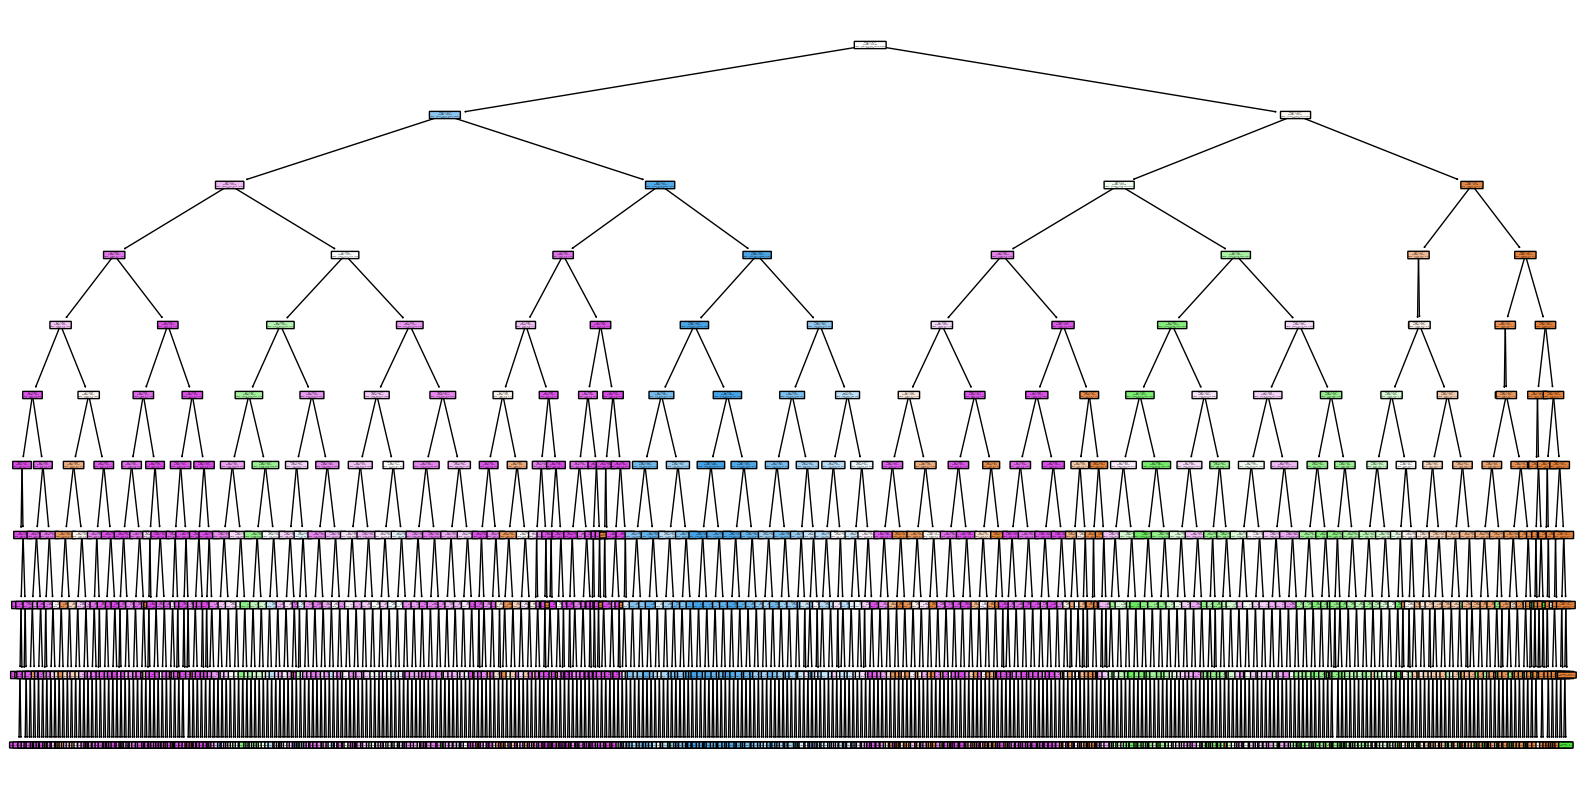

In [14]:
# Ensure feature names
feature_names = X1.columns if isinstance(X1, pd.DataFrame) else ["Feature_" + str(i) for i in range(X1.shape[1])]

# Ensure class names
class_names = [str(cls) for cls in np.unique(fes.y1)]

# Plot the decision tree
plt.figure(figsize=(20, 10))
plot_tree(
    best_dt_model_1,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    rounded=True
)
plt.show()

In [16]:
# Save the model to a file
joblib.dump(best_dt_model_1, '../models/model_decision_tree_214.pkl')

['../models/model_decision_tree_214.pkl']

# Grid Search for BiPo212

In [17]:
# Perform Grid Search for BiPo 212
print("Performing Grid Search for BiPo 212")
best_dt_model_2 = perform_grid_search(X2_train, y2_train, param_grid)

Performing Grid Search for BiPo 212
Fitting 3 folds for each of 36 candidates, totalling 108 fits
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=5; total time= 1.6min
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2; total time= 1.7min
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2; total time= 1.7min
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=2; total time= 1.8min
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=5; total time= 1.8min
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=5; total time= 1.7min
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=10; total time= 1.8min
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=10; total time= 1.7min
[CV] END max_depth=None, min_samples_leaf=2, min_samples_split=2; total time= 1.6min
[CV] END max_depth=None, min_samples_leaf=2, min_samples_split=2; total time= 1.6min
[CV] END max_depth=None, min_samples_leaf=1, min_s

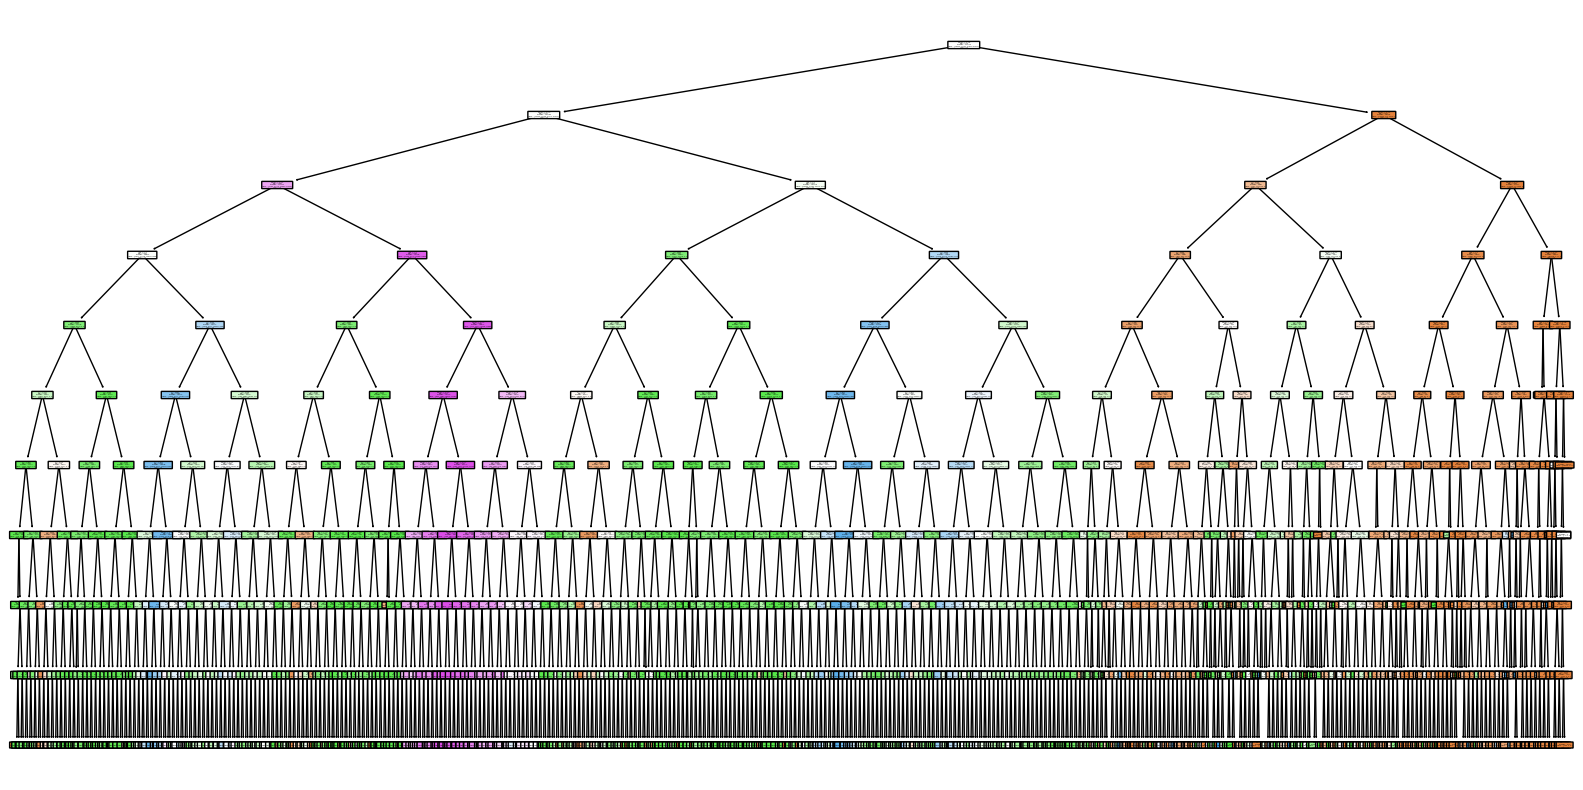

In [18]:
# Ensure feature names
feature_names = X2.columns if isinstance(X2, pd.DataFrame) else ["Feature_" + str(i) for i in range(X2.shape[1])]

# Ensure class names
class_names = [str(cls) for cls in np.unique(fes.y2)]

# Plot the decision tree
plt.figure(figsize=(20, 10))
plot_tree(
    best_dt_model_2,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    rounded=True
)
plt.show()

In [20]:
# Save the model to a file
joblib.dump(best_dt_model_2, '../models/model_decision_tree_212.pkl')

['../models/model_decision_tree_212.pkl']